### Cluster Analysis

In order to know how good or bad the clustering I did is performing, analysis of the clustering is needed. 

For analysis I have:
- reduced the dimentions and selected 2d vector for plotting
- plotted the distribution of the clusters across those two features
- plotted the distribution for outliers - documents which barely belong to a cluster or in mathematical terms documents whose probability of being the part of a cluster is very less
- for the outlier plotting I have kept the threshold probability as 0.1 (< 0.1 are outliers)
- plotted the entropies - entropy determine the uncertainity of a document belonging to one or more clusters. Entropy nearer to 0 means that document is placed in such a cluster where it strongly belongs there is not doubt.
- plotted the distribution of such uncertain documents.
- computed the TFIDF (Term Frequency Inverse Document Frequency) for each cluster and showed the top 5 words present in each cluster showing the probable cluster topic.

In [11]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def project_embeddings(embeddings):

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=42
    )

    embedding_2d = reducer.fit_transform(embeddings)

    return embedding_2d

In [12]:
def plot_cluster_map(embedding_2d, cluster_labels):

    plt.figure(figsize=(12,8))

    scatter = plt.scatter(
        embedding_2d[:,0],
        embedding_2d[:,1],
        c=cluster_labels,
        cmap="tab20",
        s=5,
        alpha=0.7
    )

    plt.title("Semantic Structure of 20 Newsgroups (UMAP Projection)")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")

    plt.colorbar(scatter, label="Cluster ID")

    plt.show()

In [13]:
def plot_cluster_distribution(cluster_labels):

    plt.figure(figsize=(10,6))

    sns.countplot(x=cluster_labels)

    plt.title("Cluster Size Distribution")
    plt.xlabel("Cluster ID")
    plt.ylabel("Number of Documents")

    plt.show()

In [14]:
def find_boundary_docs(cluster_probs, threshold=0.1):

    boundary_indices = []

    for i, probs in enumerate(cluster_probs):

        top2 = np.sort(probs)[-2:]

        if abs(top2[1] - top2[0]) < threshold:
            boundary_indices.append(i)

    return boundary_indices

In [15]:
def plot_boundary_documents(embedding_2d, boundary_indices):

    plt.figure(figsize=(12,8))

    plt.scatter(
        embedding_2d[:,0],
        embedding_2d[:,1],
        s=5,
        alpha=0.2,
        label="Normal Documents"
    )

    boundary_points = embedding_2d[boundary_indices]

    plt.scatter(
        boundary_points[:,0],
        boundary_points[:,1],
        color="red",
        s=20,
        label="Boundary Documents"
    )

    plt.title("Boundary Documents Between Clusters")

    plt.legend()

    plt.show()

In [16]:
from scipy.stats import entropy

def compute_entropy(cluster_probs):

    entropies = [entropy(p) for p in cluster_probs]

    return np.array(entropies)

In [17]:
from scipy.stats import entropy

def compute_entropy(cluster_probs):

    entropies = [entropy(p) for p in cluster_probs]

    return np.array(entropies)

def plot_entropy_distribution(entropies):

    plt.figure(figsize=(10,6))

    sns.histplot(entropies, bins=40)

    plt.title("Cluster Assignment Uncertainty (Entropy)")
    plt.xlabel("Entropy")
    plt.ylabel("Number of Documents")

    plt.show()

In [31]:
def plot_uncertain_documents(embedding_2d, entropies):

    threshold = np.percentile(entropies, 95)

    uncertain_indices = np.where(entropies >= threshold)[0]

    plt.figure(figsize=(12,8))

    plt.scatter(
        embedding_2d[:,0],
        embedding_2d[:,1],
        s=5,
        alpha=0.2
    )

    plt.scatter(
        embedding_2d[uncertain_indices,0],
        embedding_2d[uncertain_indices,1],
        color="orange",
        s=20,
        label="High Uncertainty Documents"
    )

    plt.title("Documents With High Semantic Uncertainty")

    plt.legend()

    plt.show()

In [40]:
import numpy as np
import pandas as pd
import ast

embeddings = np.load("embeddings.npy")
df = pd.read_csv("clustered_dataset.csv")

df["cluster_probs"] = df["cluster_probs"].apply(ast.literal_eval)
cluster_probs = df["cluster_probs"].tolist()
dominant_clusters = df["dominant_cluster"].tolist()

embedding_2d = project_embeddings(embeddings)

/media/ashmit/External Storage/VIT/Academics/Sixth Semester/trademarkia/semantic_search/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### Cluster Distribution over a 2D feature set

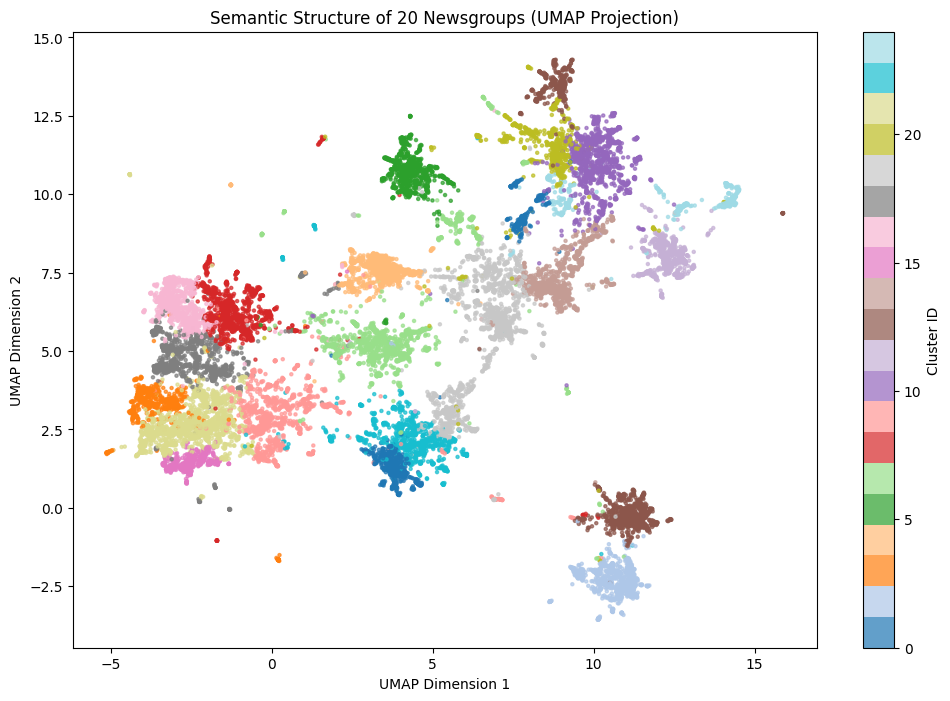

In [41]:
plot_cluster_map(embedding_2d, dominant_clusters)

#### No. of documents in each cluster

We can see that cluster 22 has largest no. of documents and cluster 7 has the least.

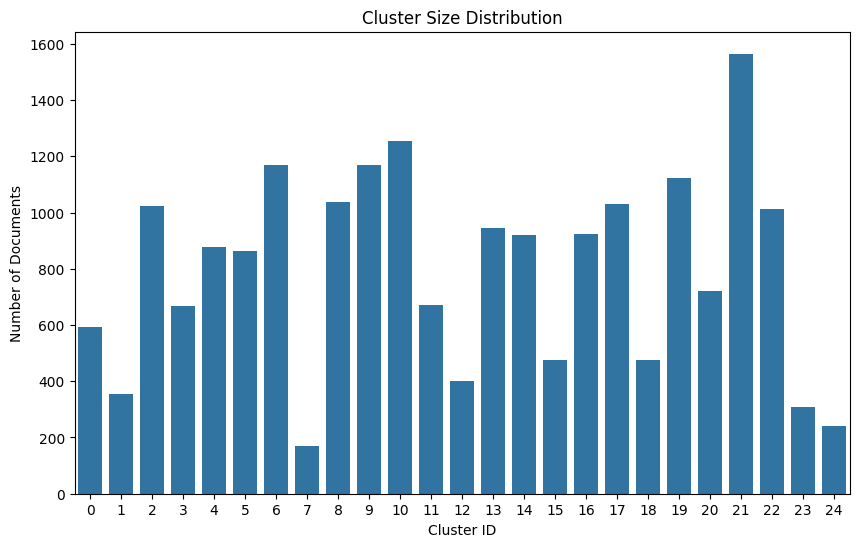

In [24]:
plot_cluster_distribution(dominant_clusters)

#### Plot showing boundary documents

As we can observe there are very less boundary documents.

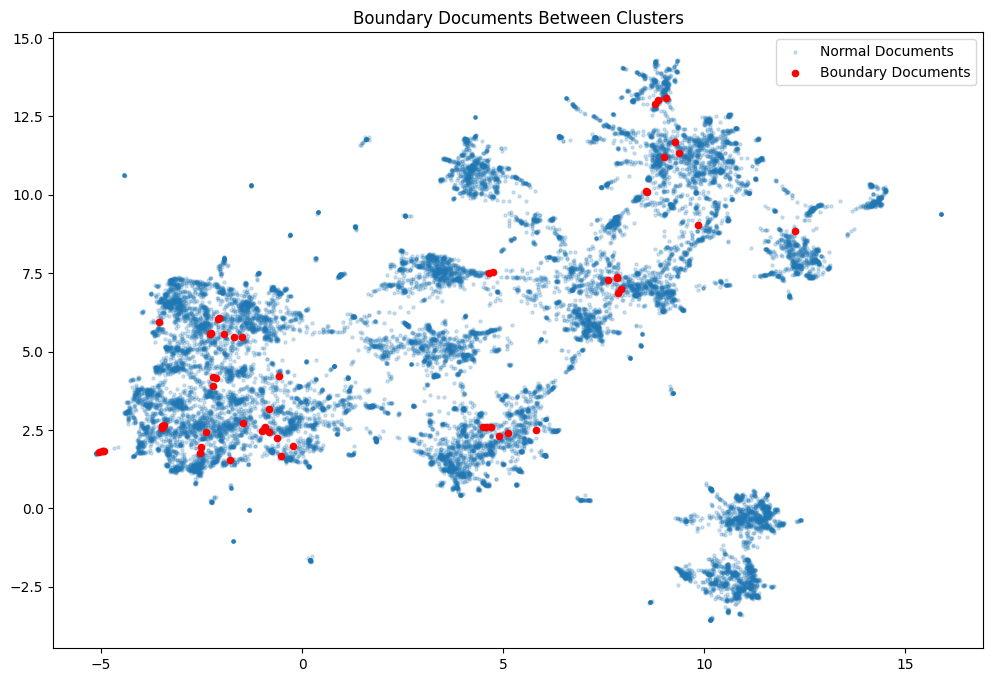

In [25]:
boundary_docs = find_boundary_docs(cluster_probs)

plot_boundary_documents(embedding_2d, boundary_docs)

#### Cluster entropy

From the histogram we can observe that most of the documents (about 17500 out of 20000) have an entropy near to 0. This shows that our clustering is very certain that a document belongs to a particular cluster. From this we can conclude that our clustering decisions were good. 

[1.97337041e-19 1.90717419e-05 1.39635722e-03 ... 1.72032369e-12
 2.31624386e-08 2.36616257e-09]


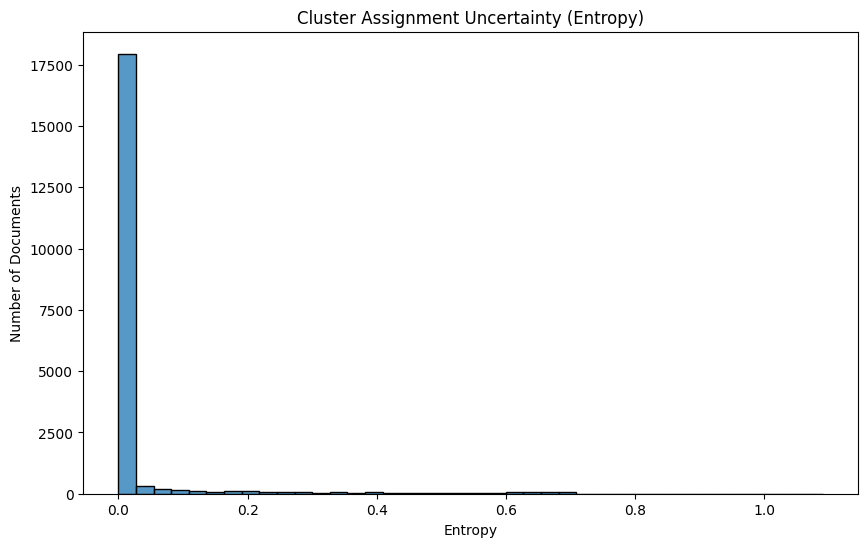

In [28]:

entropies = compute_entropy(cluster_probs)
print(entropies)

plot_entropy_distribution(entropies)

#### Plot the top 95th percentile of uncertain documents

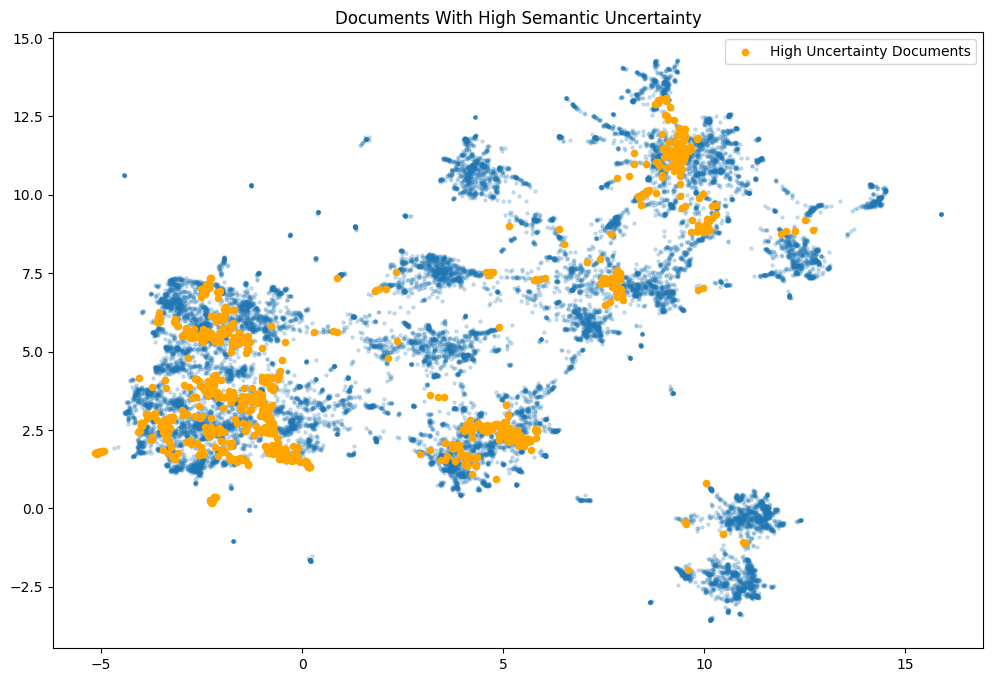

In [32]:

plot_uncertain_documents(embedding_2d, entropies)

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

def get_cluster_keywords(texts, labels, cluster_id):

    cluster_docs = [
        texts[i]
        for i in range(len(texts))
        if labels[i] == cluster_id
    ]

    vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")

    X = vectorizer.fit_transform(cluster_docs)

    scores = X.mean(axis=0).A1

    words = vectorizer.get_feature_names_out()

    top_indices = scores.argsort()[-5:][::-1]

    return [words[i] for i in top_indices]

#### Top keywords for every cluster

From this we can have an idea of what a cluster talks about although keywords are not fully realiable for knowing the subject and does not tell anything about the context, still we can have an idea about a cluster from this.

In [39]:
texts = df["clean_text"].tolist()
labels = df["dominant_cluster"].tolist()
n_clusters = 25

for cluster_id in range(n_clusters):

    keywords = get_cluster_keywords(texts, labels, cluster_id)

    print(f"\nCluster {cluster_id}")
    print(keywords)


Cluster 0
['car', 'edu', 'com', 'writes', 'new']

Cluster 1
['edu', 'gay', 'cramer', 'com', 'people']

Cluster 2
['game', 'edu', 'hockey', 'team', 'writes']

Cluster 3
['card', 'monitor', 'video', 'drivers', 'edu']

Cluster 4
['key', 'clipper', 'chip', 'encryption', 'com']

Cluster 5
['edu', 'com', 'article', 'writes', 'msg']

Cluster 6
['space', 'edu', 'writes', 'com', 'article']

Cluster 7
['abortion', 'insurance', 'health', 'coverage', 'edu']

Cluster 8
['edu', 'graphics', 'thanks', 'image', 'files']

Cluster 9
['sale', 'edu', 'com', 'writes', 'like']

Cluster 10
['god', 'edu', 'jesus', 'people', 'writes']

Cluster 11
['israel', 'edu', 'israeli', 'jews', 'writes']

Cluster 12
['objective', 'morality', 'moral', 'frank', 'say']

Cluster 13
['edu', 'game', 'writes', 'baseball', 'year']

Cluster 14
['edu', 'com', 'fbi', 'writes', 'koresh']

Cluster 15
['drive', 'scsi', 'ide', 'disk', 'hard']

Cluster 16
['window', 'windows', 'motif', 'server', 'thanks']

Cluster 17
['windows', 'edu', '